Series de Fourier: Magnitud y Fase

Integrantes: 

- Valentina Morales
- Paula García

a) Construya una señal cuadrada y triangular periódica, definiendo su frecuencia fundamental, amplitud y
número de muestras

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal as sig

In [3]:
f0 = 5          
T0 = 1 / f0     
A = 1            
N = 500          

t = np.linspace(0, T0, N, endpoint=False)  

# a) Señal cuadrada periódica
x_sq = A * sig.square(2 * np.pi * f0 * t)

# b) Señal triangular periódica (width=0.5 -> triangular simétrica)
x_tri = A * sig.sawtooth(2 * np.pi * f0 * t, width=0.5)

print(f"f0 = {f0} Hz, T0 = {T0*1000:.1f} ms, A = {A}, N = {N} muestras/periodo")

f0 = 5 Hz, T0 = 200.0 ms, A = 1, N = 500 muestras/periodo


c) Grafique ambas señales en el dominio del tiempo.

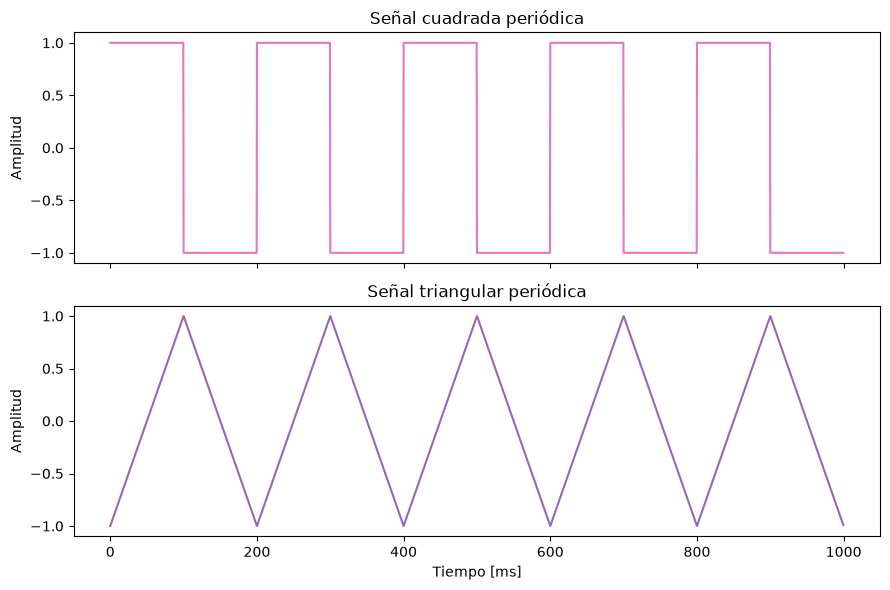

In [4]:
n_periodos = 5
t_rep = np.concatenate([t + k * T0 for k in range(n_periodos)])
x_sq_rep = np.tile(x_sq, n_periodos)
x_tri_rep = np.tile(x_tri, n_periodos)

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].plot(t_rep * 1000, x_sq_rep, color='tab:pink')
axs[0].set_title('Señal cuadrada periódica')
axs[0].set_ylabel('Amplitud')

axs[1].plot(t_rep * 1000, x_tri_rep, color='tab:purple')
axs[1].set_title('Señal triangular periódica')
axs[1].set_xlabel('Tiempo [ms]')
axs[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier
(forma exponencial), calculados mediante NumPy.

In [5]:
def coeficientes_fourier(x):
    """
    Calcula los coeficientes de Fourier de una señal periódica x[n] utilizando la Transformada Rápida de Fourier (FFT).
    """
    x = np.asarray(x)
    N = len(x)
    c_k = np.fft.fftshift(np.fft.fft(x) / N)
    k = np.fft.fftshift(np.fft.fftfreq(N, d=1/N)).astype(int)
    return k, c_k

https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html

E) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos
coeficientes

In [8]:
k_sq, c_sq = coeficientes_fourier(x_sq)
k_tri, c_tri = coeficientes_fourier(x_tri)

print("Primeros coeficientes (cuadrada):")
for kk, cc in zip(k_sq[N//2:N//2+6], c_sq[N//2:N//2+6]):
    print(f"  c[{kk}] = {cc:.4f}  |c[{kk}]| = {abs(cc):.4f}")

print("\nPrimeros coeficientes (triangular):")
for kk, cc in zip(k_tri[N//2:N//2+6], c_tri[N//2:N//2+6]):
    print(f"  c[{kk}] = {cc:.4f}  |c[{kk}]| = {abs(cc):.4f}")

Primeros coeficientes (cuadrada):
  c[0] = 0.0000+0.0000j  |c[0]| = 0.0000
  c[1] = 0.0040-0.6366j  |c[1]| = 0.6366
  c[2] = 0.0000+0.0000j  |c[2]| = 0.0000
  c[3] = 0.0040-0.2122j  |c[3]| = 0.2122
  c[4] = 0.0000+0.0000j  |c[4]| = 0.0000
  c[5] = 0.0040-0.1273j  |c[5]| = 0.1273

Primeros coeficientes (triangular):
  c[0] = -0.0000+0.0000j  |c[0]| = 0.0000
  c[1] = -0.4053-0.0000j  |c[1]| = 0.4053
  c[2] = 0.0000+0.0000j  |c[2]| = 0.0000
  c[3] = -0.0450-0.0000j  |c[3]| = 0.0450
  c[4] = 0.0000+0.0000j  |c[4]| = 0.0000
  c[5] = -0.0162-0.0000j  |c[5]| = 0.0162


F) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de
magnitud y el espectro de fase correspondientes

G) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular.

H) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo
como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.


I) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y
grafique cada reconstrucción junto con la señal original.


J) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal
cuadrada.

K) Cargue una señal ECG sin ruido y su composición espectral. Consulte y describa brevemente los
componentes de frecuencia principales asociados a las ondas P, al complejo QRS y a la onda T.